Using device: cpu
Loading model...


config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  982MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  982MB            

...

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

Model loaded successfully!

Please upload an image:


Saving pug-dog-isolated-white-background_2829-11416.avif to pug-dog-isolated-white-background_2829-11416.avif
Image selected: pug-dog-isolated-white-background_2829-11416.avif
Image loaded successfully!
Image size: (740, 740)


[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.



IMAGE CAPTIONING RESULT
Image: pug-dog-isolated-white-background_2829-11416.avif
Generated Caption: a white and brown dog with a black collar 


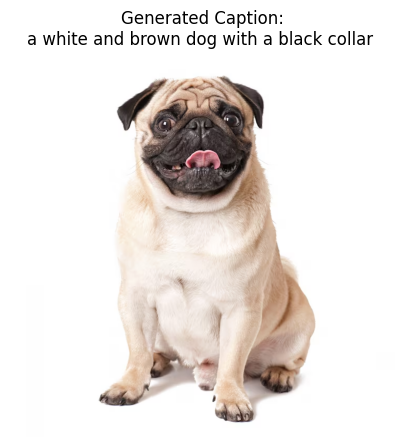

In [1]:
# ============================================================
# EXP 7: IMAGE CAPTIONING USING ViT + GPT-2
# ============================================================

# Install required libraries
!pip -q install transformers

import torch
from PIL import Image
from transformers import (
    VisionEncoderDecoderModel,
    ViTImageProcessor,
    AutoTokenizer
)
from google.colab import files

# ------------------------------------------------------------
# 1. Select Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("Loading model...")

# ------------------------------------------------------------
# 2. Load Pretrained ViT-GPT2 Model
# ------------------------------------------------------------
model_name = "nlpconnect/vit-gpt2-image-captioning"

model = VisionEncoderDecoderModel.from_pretrained(model_name)
processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

model.to(device)
model.eval()

print("Model loaded successfully!")

# ------------------------------------------------------------
# 3. Upload Image
# ------------------------------------------------------------
print("\nPlease upload an image:")

uploaded = files.upload()

# Get uploaded filename automatically
image_path = list(uploaded.keys())[0]

print("Image selected:", image_path)

# ------------------------------------------------------------
# 4. Open Image
# ------------------------------------------------------------
image = Image.open(image_path).convert("RGB")

print("Image loaded successfully!")
print("Image size:", image.size)

# ------------------------------------------------------------
# 5. Preprocess Image
# ------------------------------------------------------------
pixel_values = processor(
    images=image,
    return_tensors="pt"
).pixel_values

pixel_values = pixel_values.to(device)

# ------------------------------------------------------------
# 6. Generate Caption
# ------------------------------------------------------------
with torch.no_grad():

    output_ids = model.generate(
        pixel_values,
        max_length=20,
        num_beams=2,
        early_stopping=True
    )

# ------------------------------------------------------------
# 7. Decode Caption
# ------------------------------------------------------------
caption = tokenizer.decode(
    output_ids[0],
    skip_special_tokens=True
)

# ------------------------------------------------------------
# 8. Display Result
# ------------------------------------------------------------
print("\n" + "=" * 50)
print("IMAGE CAPTIONING RESULT")
print("=" * 50)

print("Image:", image_path)
print("Generated Caption:", caption)

print("=" * 50)

# ------------------------------------------------------------
# 9. Display Image
# ------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Caption:\n" + caption)
plt.show()